# Experiment 8: Random Forests

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** Ensemble Learning — Random Forest Classifier on Breast Cancer dataset  
**Dataset:** `sklearn.datasets.load_breast_cancer() (569 samples, 30 features, 2 classes)`  
**Lab Book Reference:** §12 Random Forests, page 53–58

---

## 🎯 Objective

Implement a **Random Forest Classifier** on the Breast Cancer dataset. We start with the Lab Book's exact configuration (`n_estimators=10, criterion='entropy'`), then build an enhanced model with 200 trees, Out-Of-Bag (OOB) evaluation, feature importance, ROC curve, and a comparison against a single Decision Tree to demonstrate the **ensemble effect**.

## ▶️ How to Run This Notebook

> **Option A — Google Colab (recommended if you don't have Python locally):**
> 1. Upload the entire `ML-Lab-Activities-Complete` folder to your Google Drive
>    (so it appears at `My Drive/ML-Lab-Activities-Complete/`).
> 2. In Colab, `File → Open notebook → Google Drive → 08-Random-Forests/08_*.ipynb`.
> 3. The first code cell auto-mounts Drive, chdir's to this experiment folder,
>    and creates an `outputs/` subfolder for every figure.
>
> **Option B — Local Jupyter:**
> ```bash
> # 1. (optional) create a virtual-env
> python -m venv .venv && source .venv/bin/activate
>
> # 2. install dependencies (one-time)
> pip install -r requirements.txt
>
> # 3. launch Jupyter from the repository root
> jupyter notebook 08-Random-Forests/08_*.ipynb
> ```
>
> **Option C — Headless execution:**
> ```bash
> jupyter nbconvert --to notebook --execute \
>   08-Random-Forests/08_*.ipynb \
>   --output executed.ipynb
> ```

Datasets are read from `../datasets/` (relative to the notebook's folder).
Generated figures are **auto-saved** to `./outputs/` inside this experiment's folder.


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    # Adjust this path if you placed the folder elsewhere in your Drive
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '08-Random-Forests'))
    print(f'Running in Google Colab. Changed CWD to: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

# Create outputs/ folder in this experiment's directory
OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# --- Auto-save every matplotlib figure to outputs/ ---
# We patch plt.show() so that BEFORE a figure is shown, it is also saved
# to the outputs/ folder.  In the Jupyter inline backend, plt.show() is
# essentially a no-op (display happens automatically at cell-end), but it
# is still called inside every plotting cell — so this is the right hook.
import matplotlib.pyplot as plt

_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    # Save every currently-open figure before showing
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('✅ Setup complete.')
print(f'   Datasets will be read from: {os.path.join(os.getcwd(), "..", "datasets")}')
print(f'   Figures will be auto-saved to: {OUTPUT_DIR}')


Running locally. CWD: /home/z/my-project/work/final/08-Random-Forests


✅ Setup complete.
   Datasets will be read from: /home/z/my-project/work/final/08-Random-Forests/../datasets
   Figures will be auto-saved to: /home/z/my-project/work/final/08-Random-Forests/outputs


## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_breast_cancer
from sklearn import metrics
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             classification_report, roc_curve, auc,
                             precision_score, recall_score, f1_score)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
import warnings; warnings.filterwarnings('ignore')
print("Libraries imported.")


Libraries imported.


## 2. Load & Explore Dataset

The Breast Cancer Wisconsin (Diagnostic) dataset bundled with scikit-learn contains **569 samples**
with **30 numeric features** computed from a digitised image of a fine-needle aspirate (FNA) of a
breast mass. The target is binary: **0 = malignant**, **1 = benign**. This is the same dataset
referenced in the Lab Activity Book, page 54.


In [3]:
cancer = load_breast_cancer()
print("Keys:", list(cancer.keys()))
print("\nTarget names :", cancer.target_names)
print("Feature count :", len(cancer.feature_names))
print("Samples       :", cancer.data.shape[0])


Keys: ['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module']

Target names : ['malignant' 'benign']
Feature count : 30
Samples       : 569


In [4]:
data = pd.DataFrame(cancer.data, columns=cancer.feature_names)
data['target']   = cancer.target
data['diagnosis'] = data['target'].map({0: 'malignant', 1: 'benign'})

print(f"Dataset shape: {data.shape}")
display(data.head())

print("\nClass distribution:")
print(data['diagnosis'].value_counts())
print("\nPercentage:")
print((data['diagnosis'].value_counts(normalize=True) * 100).round(2))


Dataset shape: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant



Class distribution:
diagnosis
benign       357
malignant    212
Name: count, dtype: int64

Percentage:
diagnosis
benign       62.74
malignant    37.26
Name: proportion, dtype: float64


## 3. Check for Null Values

In [5]:
null_counts = data.iloc[:, :-2].isnull().sum()
print(f"Total null values in feature columns: {null_counts.sum()}")
print("✅ Dataset is clean — no missing values to handle." if null_counts.sum() == 0 else "⚠ Missing values detected.")


Total null values in feature columns: 0
✅ Dataset is clean — no missing values to handle.


## 4. Define Features (X) and Target (y)

In [6]:
feature_cols = list(cancer.feature_names)
X = data[feature_cols].values
y = data['target'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Unique labels: {np.unique(y)}  (0 = malignant, 1 = benign)")


X shape: (569, 30)
y shape: (569,)
Unique labels: [0 1]  (0 = malignant, 1 = benign)


## 5. Split into Training and Testing Sets (70/30)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=41
)
print(f"Training: {X_train.shape}, Testing: {X_test.shape}")
print(f"\nClass balance (train): {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"Class balance (test) : {dict(zip(*np.unique(y_test, return_counts=True)))}")


Training: (398, 30), Testing: (171, 30)

Class balance (train): {np.int64(0): np.int64(151), np.int64(1): np.int64(247)}
Class balance (test) : {np.int64(0): np.int64(61), np.int64(1): np.int64(110)}


## 6. Feature Scaling

In [8]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test  = sc.transform(X_test)
print("Features standardised.")


Features standardised.


## 7. Train Random Forest — Lab Book Configuration

We use the exact Lab Book parameters: `n_estimators=10, criterion='entropy'`.


In [9]:
model = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Random Forest Classifier (n_estimators=10, criterion='entropy')")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"\nAccuracy Score : {acc:.6f}")
print(f"Accuracy in %   : {int(acc * 100)}%")
print("\nClassification Report:")
print(classification_report(y_pred, y_test, target_names=['malignant', 'benign']))


Random Forest Classifier (n_estimators=10, criterion='entropy')
Confusion Matrix:
[[ 61   0]
 [  2 108]]

Accuracy Score : 0.988304
Accuracy in %   : 98%

Classification Report:
              precision    recall  f1-score   support

   malignant       1.00      0.97      0.98        63
      benign       0.98      1.00      0.99       108

    accuracy                           0.99       171
   macro avg       0.99      0.98      0.99       171
weighted avg       0.99      0.99      0.99       171



## 8. Enhanced Random Forest (200 trees + OOB evaluation)

Increasing the number of trees improves stability and reduces variance. We also enable
**Out-Of-Bag (OOB) evaluation** — Random Forest's built-in validation mechanism that uses the
~37 % of training samples not selected in each bootstrap sample to estimate generalisation error
without needing a separate validation set.


In [10]:
model_enh = RandomForestClassifier(
    n_estimators=200,
    criterion='gini',
    max_features='sqrt',
    min_samples_split=5,
    min_samples_leaf=2,
    bootstrap=True,
    oob_score=True,
    n_jobs=-1,
    random_state=42,
)
model_enh.fit(X_train, y_train)

y_pred_enh = model_enh.predict(X_test)
y_proba_enh = model_enh.predict_proba(X_test)[:, 1]

acc_enh = accuracy_score(y_test, y_pred_enh)
print(f"Enhanced Random Forest (n_estimators=200)")
print(f"Accuracy       : {acc_enh:.6f}  ({acc_enh*100:.2f}%)")
print(f"OOB Score      : {model_enh.oob_score_:.6f}")
print(f"Precision      : {precision_score(y_test, y_pred_enh):.4f}")
print(f"Recall         : {recall_score(y_test, y_pred_enh):.4f}")
print(f"F1 Score       : {f1_score(y_test, y_pred_enh):.4f}")


Enhanced Random Forest (n_estimators=200)
Accuracy       : 0.988304  (98.83%)
OOB Score      : 0.944724
Precision      : 1.0000
Recall         : 0.9818
F1 Score       : 0.9908


## 9. Confusion Matrix

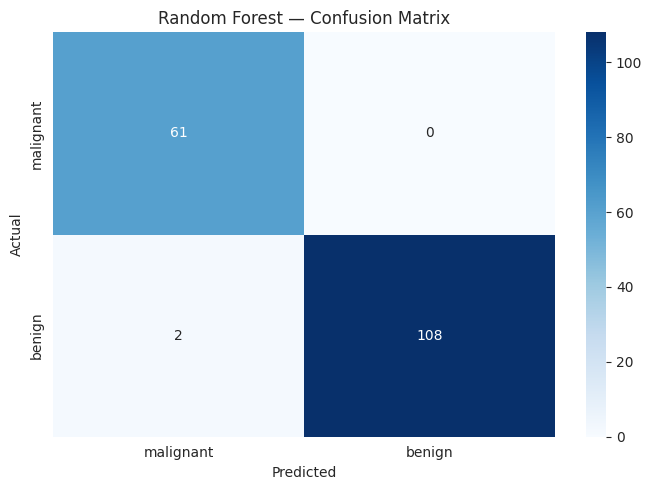

TN (malignant correct) : 61
FP (malignant → benign): 0
FN (benign → malignant): 2
TP (benign correct)    : 108

Recall (sensitivity, critical in cancer screening): 0.9818


In [11]:
cm = confusion_matrix(y_test, y_pred_enh)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['malignant', 'benign'],
            yticklabels=['malignant', 'benign'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TN (malignant correct) : {tn}")
print(f"FP (malignant → benign): {fp}")
print(f"FN (benign → malignant): {fn}")
print(f"TP (benign correct)    : {tp}")
print(f"\nRecall (sensitivity, critical in cancer screening): {tp/(tp+fn):.4f}")


## 10. ROC Curve & AUC

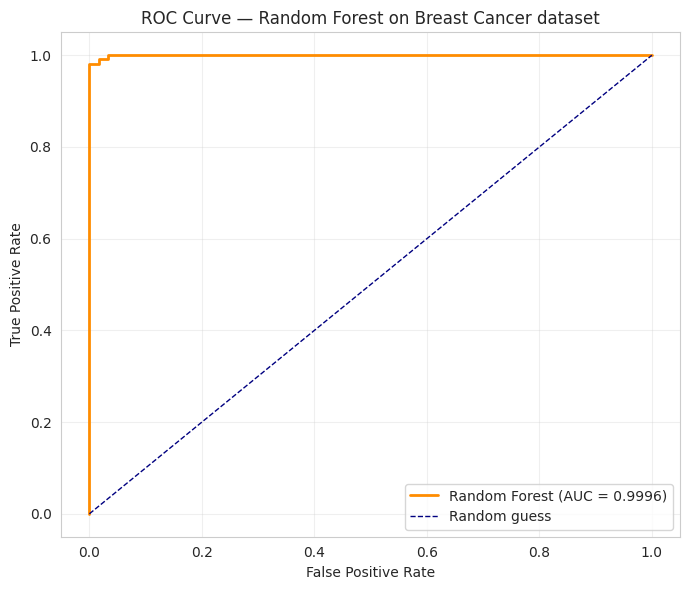

AUC-ROC: 0.9996  (>0.9 indicates excellent discrimination)


In [12]:
fpr, tpr, _ = roc_curve(y_test, y_proba_enh)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'Random Forest (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Random Forest on Breast Cancer dataset')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(f"AUC-ROC: {roc_auc:.4f}  (>0.9 indicates excellent discrimination)")


## 11. Feature Importance

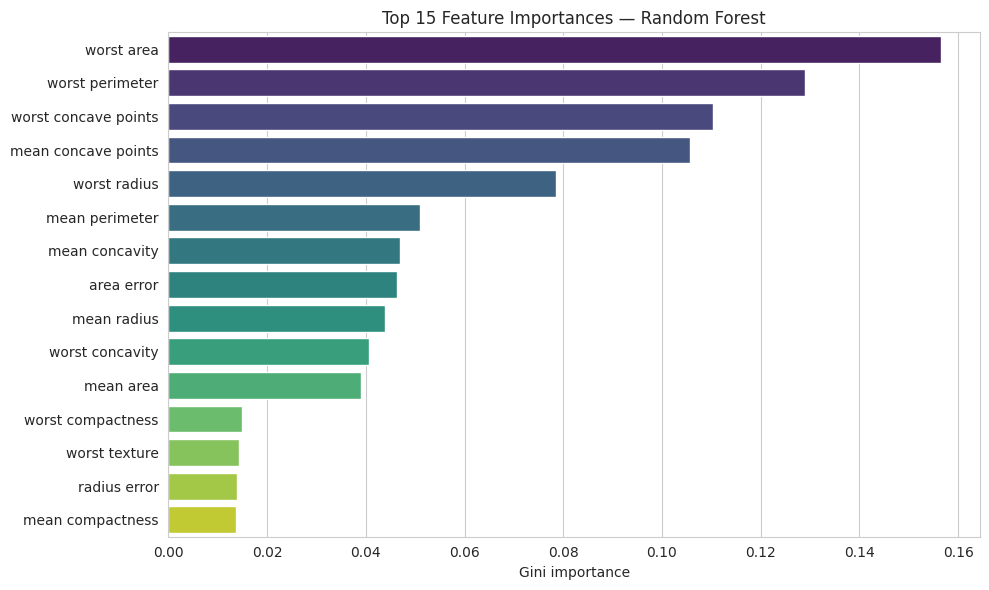

Top-10 features:
   1. worst area                      importance = 0.1566
   2. worst perimeter                 importance = 0.1290
   3. worst concave points            importance = 0.1103
   4. mean concave points             importance = 0.1057
   5. worst radius                    importance = 0.0785
   6. mean perimeter                  importance = 0.0510
   7. mean concavity                  importance = 0.0470
   8. area error                      importance = 0.0464
   9. mean radius                     importance = 0.0438
  10. worst concavity                 importance = 0.0407


In [13]:
importances = model_enh.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 15

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices[:top_n]],
            y=np.array(feature_cols)[indices[:top_n]],
            palette='viridis')
plt.title(f'Top {top_n} Feature Importances — Random Forest')
plt.xlabel('Gini importance')
plt.tight_layout()
plt.show()

print("Top-10 features:")
for rank, idx in enumerate(indices[:10], 1):
    print(f"  {rank:2d}. {feature_cols[idx]:30s}  importance = {importances[idx]:.4f}")


## 12. Visualise a Single Tree from the Forest

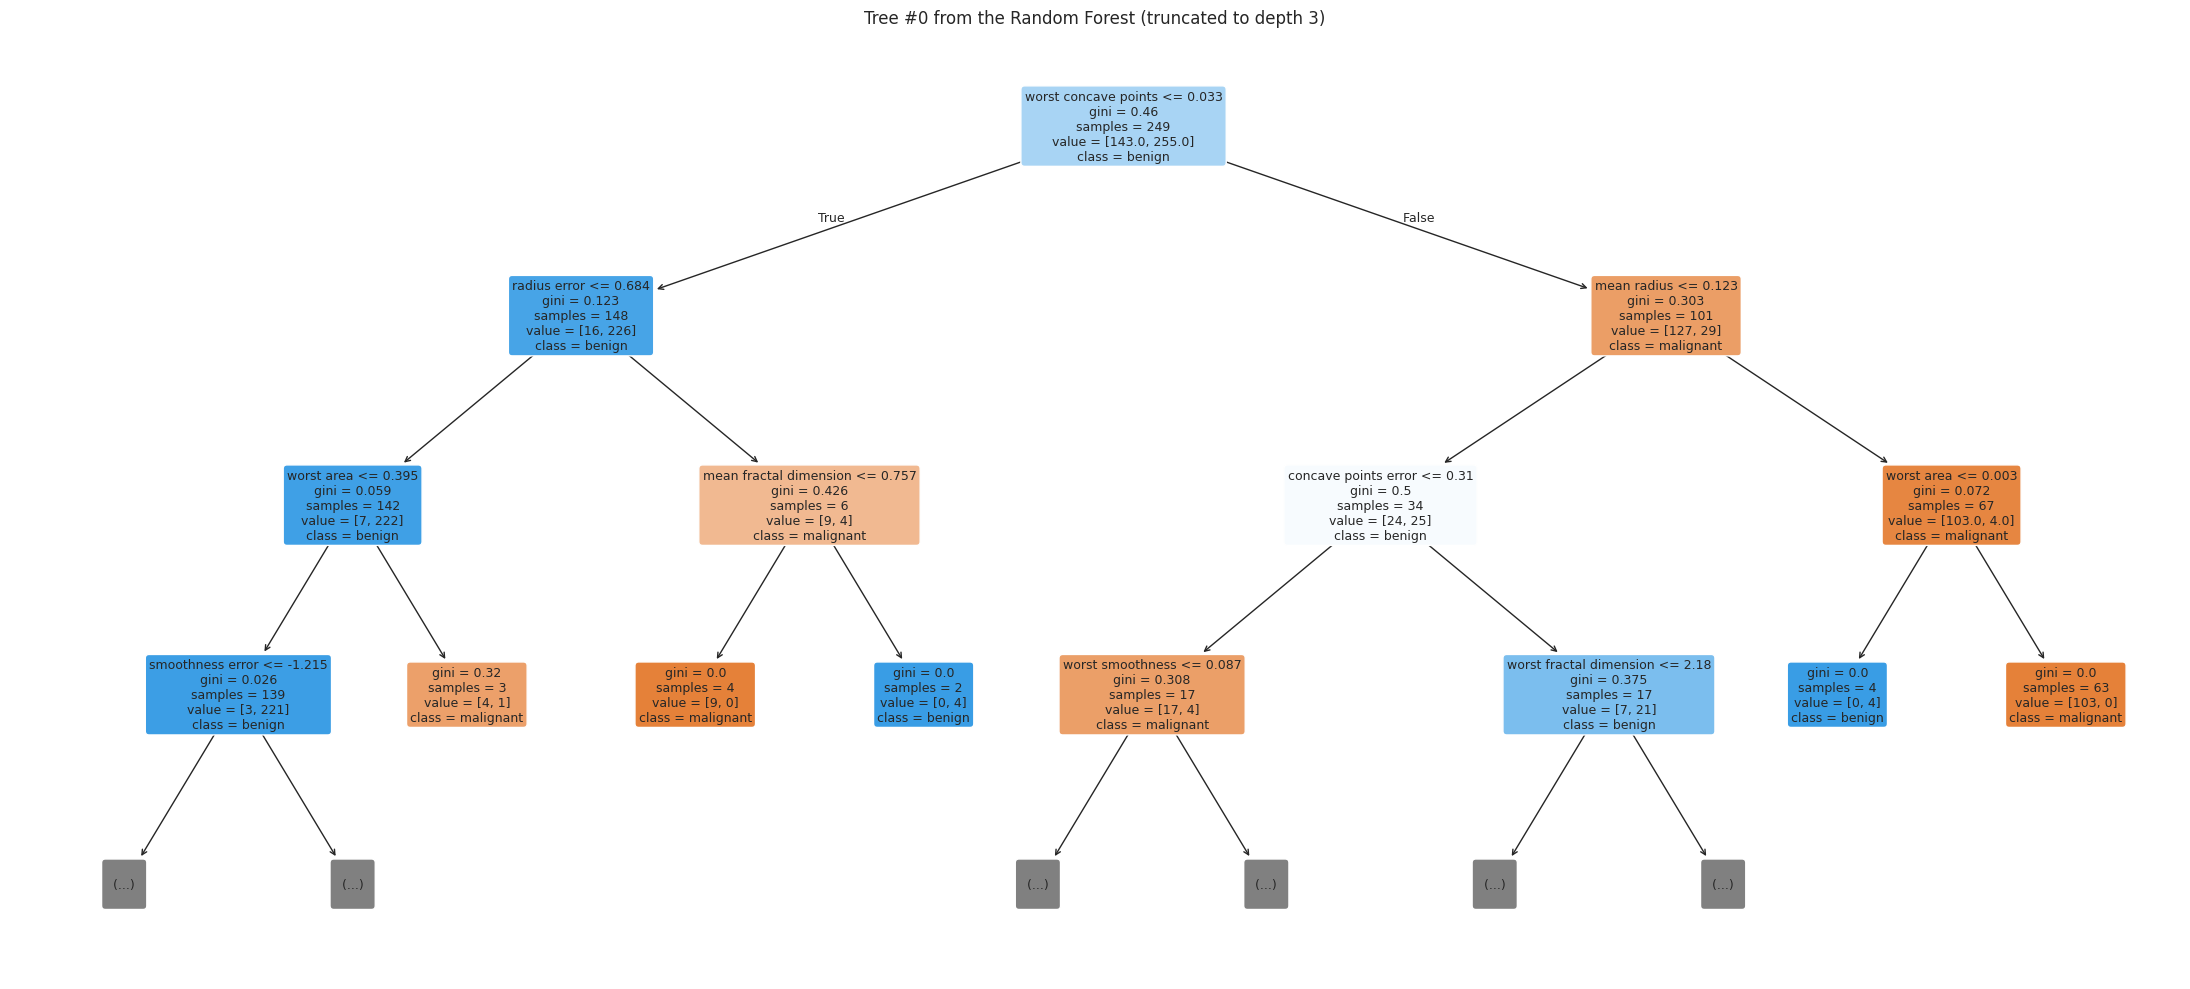

Total trees in forest: 200
Depth of this tree   : 6
Leaves in this tree  : 14


In [14]:
single_tree = model_enh.estimators_[0]

plt.figure(figsize=(22, 10))
plot_tree(single_tree,
          feature_names=feature_cols,
          class_names=['malignant', 'benign'],
          filled=True, rounded=True,
          max_depth=3, fontsize=9)
plt.title('Tree #0 from the Random Forest (truncated to depth 3)')
plt.tight_layout()
plt.show()

print(f"Total trees in forest: {model_enh.n_estimators}")
print(f"Depth of this tree   : {single_tree.get_depth()}")
print(f"Leaves in this tree  : {single_tree.get_n_leaves()}")


## 13. Hyperparameter Sweep — `n_estimators`

We vary the number of trees from 10 → 500 to confirm that performance plateaus after a point
(classic Random Forest behaviour).


 n_estimators  Train Accuracy  Test Accuracy  OOB Score
           10        0.992462       0.976608   0.919598
           25        1.000000       0.982456   0.937186
           50        1.000000       0.982456   0.947236
          100        1.000000       0.988304   0.952261
          150        1.000000       0.988304   0.957286
          200        1.000000       0.982456   0.957286
          300        1.000000       0.982456   0.959799
          500        1.000000       0.988304   0.952261


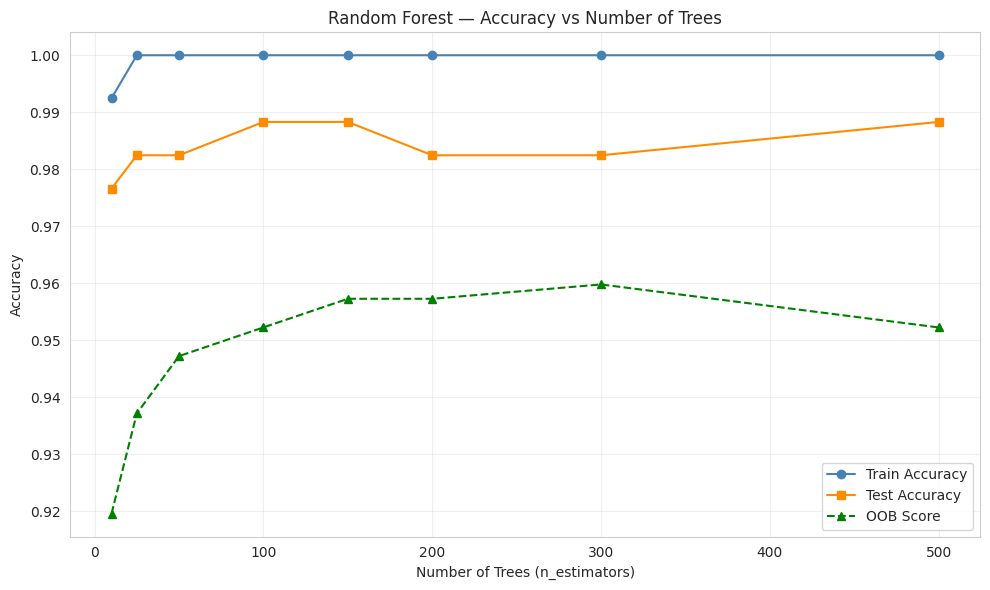

In [15]:
n_trees_list = [10, 25, 50, 100, 150, 200, 300, 500]
train_acc, test_acc, oob_acc = [], [], []

for n in n_trees_list:
    rf = RandomForestClassifier(n_estimators=n, oob_score=True,
                                random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    train_acc.append(rf.score(X_train, y_train))
    test_acc.append(rf.score(X_test,  y_test))
    oob_acc.append(rf.oob_score_)

results_df = pd.DataFrame({
    'n_estimators'  : n_trees_list,
    'Train Accuracy': train_acc,
    'Test Accuracy' : test_acc,
    'OOB Score'     : oob_acc,
})
print(results_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.plot(n_trees_list, train_acc, 'o-', label='Train Accuracy', color='steelblue')
plt.plot(n_trees_list, test_acc, 's-', label='Test Accuracy',  color='darkorange')
plt.plot(n_trees_list, oob_acc,  '^--', label='OOB Score',      color='green')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.title('Random Forest — Accuracy vs Number of Trees')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 14. Comparison: Single Decision Tree vs Random Forest

To demonstrate the **ensemble effect**, we compare the Random Forest against a single
Decision Tree trained on the same data.


In [16]:
dt = DecisionTreeClassifier(criterion='gini', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

comparison = pd.DataFrame({
    'Model'     : ['Single Decision Tree', 'Random Forest (200 trees)'],
    'Accuracy'  : [accuracy_score(y_test, y_pred_dt),
                   accuracy_score(y_test, y_pred_enh)],
    'Precision' : [precision_score(y_test, y_pred_dt),
                   precision_score(y_test, y_pred_enh)],
    'Recall'    : [recall_score(y_test, y_pred_dt),
                   recall_score(y_test, y_pred_enh)],
    'F1 Score'  : [f1_score(y_test, y_pred_dt),
                   f1_score(y_test, y_pred_enh)],
}).round(4)
print(comparison.to_string(index=False))
print("\n➡ Random Forest reduces variance and improves every metric vs a single tree.")


                    Model  Accuracy  Precision  Recall  F1 Score
     Single Decision Tree    0.9532     0.9811  0.9455    0.9630
Random Forest (200 trees)    0.9883     1.0000  0.9818    0.9908

➡ Random Forest reduces variance and improves every metric vs a single tree.


## 📝 Exercises

> Submit the Colab link or GitHub link or any `.ipynb` file for the exercises.

1. **Fruit-basket ensemble (Lab Book page 58).** Simulate a fruit basket with `n` samples; build 20 bootstrap decision trees and aggregate predictions via majority voting.
2. **Credit scoring.** Train a Random Forest on the *German Credit Data* dataset to predict whether a customer will default. Report top-5 important features.
3. **Hyper-parameter tuning.** Use `GridSearchCV` to find the best `n_estimators`, `max_depth`, `min_samples_split`, `max_features` on this dataset.
4. **Customer churn prediction.** Train a Random Forest on the *Telco Customer Churn* dataset and identify the top 3 churn drivers.


---

## 📚 Key Takeaways

- **Random Forest** = many decision trees + bootstrap sampling + random feature selection + majority vote.
- **Bagging** reduces variance, so RFs rarely overfit even without pruning.
- **OOB score** gives a free, unbiased generalisation estimate — no separate validation set needed.
- **Feature importance** is a powerful by-product — useful for feature selection and interpretation.
- **Trade-offs:** more trees → better accuracy but slower inference; less interpretable than a single tree; can be biased on highly imbalanced data (use `class_weight='balanced'`).
- **Real-world uses:** credit scoring, disease diagnosis, fraud detection, image recognition, customer churn prediction.

## 🔗 References

- Lab Activity Book (23CSE301), Department of CSE.
- Scikit-learn User Guide: <https://scikit-learn.org/stable/user_guide.html>
